In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("image.jpeg", 0)

In [2]:

# Convert to binary using threshold
binary = np.zeros_like(image)
binary[image > 127] = 255

In [3]:

# =================================
# Find Distance from Background
# =================================

distance = np.zeros_like(image, dtype=float)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):

        if binary[i, j] == 255:

            # Distance from image boundary
            d1 = i
            d2 = j
            d3 = image.shape[0] - i - 1
            d4 = image.shape[1] - j - 1

            distance[i, j] = min(d1, d2, d3, d4)

In [4]:
# =================================
# Create Markers
# =================================

markers = np.zeros_like(image, dtype=np.uint8)

# Foreground marker
markers[distance > 20] = 255

# Background marker
markers[binary == 0] = 100


In [5]:
# =================================
# Simple Watershed Boundary
# =================================

result = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

# Detect boundaries between foreground and background
for i in range(1, image.shape[0] - 1):
    for j in range(1, image.shape[1] - 1):

        region = binary[i-1:i+2, j-1:j+2]

        if np.any(region == 0) and np.any(region == 255):
            result[i, j] = [255, 0, 0]

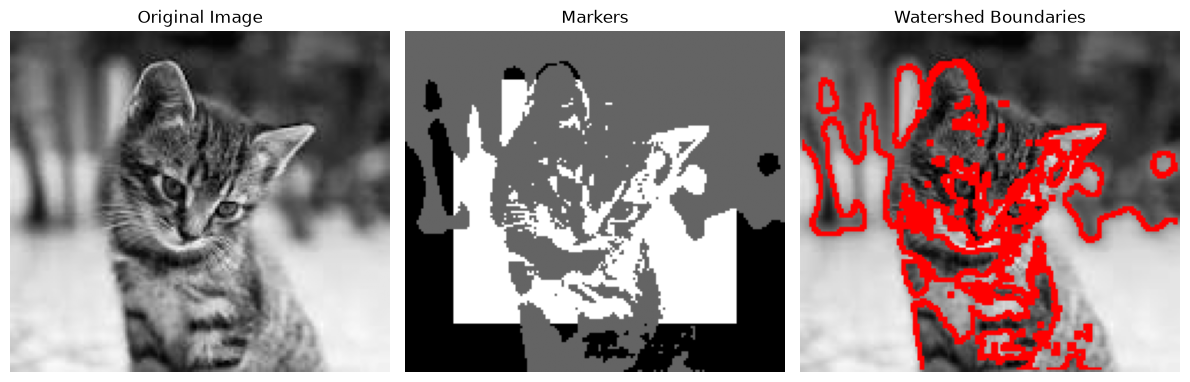

In [6]:
# =================================
# Display Results
# =================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(markers, cmap="gray")
plt.title("Markers")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title("Watershed Boundaries")
plt.axis("off")

plt.tight_layout()
plt.show()